# Lab 3 — Segmentation des districts par Clustering Hiérarchique

**Machine Learning II (ADIF84) — Projet : tableau de bord des autobus scolaires électriques aux États-Unis**

## 1. Compréhension du problème métier

**Objectif business.** Identique au TP2 : segmenter les districts **déjà engagés** dans les bus électriques pour cibler une démarche commerciale. Mais cette fois on utilise le **clustering hiérarchique** (modèle imposé par le sujet du Lab 3) au lieu de K-means.

**Question :**
> « Quels groupes de districts engagés peut-on identifier, et la structure trouvée confirme-t-elle celle du K-means (TP2) ? »

**Type de tâche (cf. chapitre 2).** Clustering **hiérarchique agglomératif** : tâche **descriptive** et **non supervisée**.

**Différence clé avec K-means (TP2) :**
| | K-means (TP2) | Hiérarchique (TP3) |
|---|---|---|
| Nombre de clusters | fixé **avant** (K) | choisi **après**, en coupant l'arbre |
| Principe | K centres qu'on ajuste | fusions successives des plus proches |
| Sortie | une partition | un **arbre (dendrogramme)** |

**Données.** On réutilise `clustering.csv` (le **même** jeu préparé au TP2 : 1524 districts engagés, 4 variables socio-économiques, déjà nettoyé et standardisé). Cela permet une **comparaison directe** des deux méthodes.


In [1]:
# =========================
# IMPORTS
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42

In [2]:
# =========================
# CHARGEMENT DES DONNÉES (déjà préparées au TP2)
# =========================
df = pd.read_csv('clustering.csv')

# noms courts pour l'affichage des profils
noms_courts = {
    '3i. Percent of fleet that is electric': '% flotte électrique',
    '4b. Number of students in district': 'Nb élèves',
    '4e. Percentage of students in district eligible for free or reduced price lunch': '% repas gratuits',
    '4g. Percent of population below the poverty level': '% pauvreté'
}

print("Dimensions :", df.shape)
print("Données déjà standardisées au TP2 (moyenne ~0, écart-type ~1) :")
df.describe().round(2).T[['mean', 'std', 'min', 'max']]

Dimensions : (1524, 4)
Données déjà standardisées au TP2 (moyenne ~0, écart-type ~1) :


,mean,std,min,max
3i. Percent of fleet that is electric,0.0,1.0,-0.91,3.82
4b. Number of students in district,-0.0,1.0,-0.37,14.97
4e. Percentage of students in district eligible for free or reduced price lunch,-0.0,1.0,-1.89,1.71
4g. Percent of population below the poverty level,-0.0,1.0,-1.97,4.92


## 2. Le dendrogramme

Le clustering hiérarchique agglomératif construit un **arbre de fusions** :
1. chaque district est d'abord son propre cluster (1524 clusters) ;
2. on fusionne à chaque étape les **deux clusters les plus proches** ;
3. on continue jusqu'à n'avoir qu'un seul cluster contenant tout.

Le **dendrogramme** visualise ces fusions : la **hauteur** d'une fusion = la distance entre les deux groupes fusionnés (plus c'est haut, plus ils étaient différents). Pour obtenir K clusters, on **« coupe » l'arbre** par une ligne horizontale : le nombre de branches coupées = le nombre de clusters.

> ⚠️ Tracer un dendrogramme avec 1524 feuilles serait illisible. On utilise donc l'option `truncate_mode='lastp'` qui n'affiche que les **dernières fusions** (les plus importantes), regroupant le bas de l'arbre.


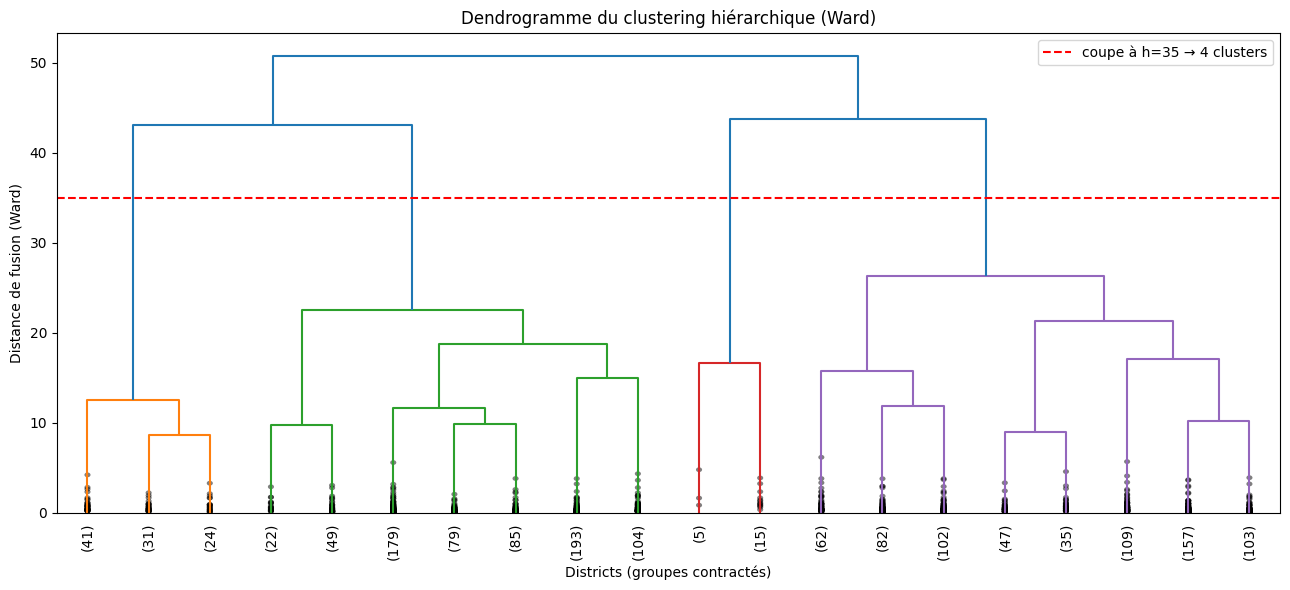

Hauteurs des 6 dernières fusions : [21.3 22.5 26.3 43.1 43.7 50.8]
=> Gros saut de ~26 à ~43 : couper à h≈35 isole proprement 4 groupes.


In [3]:
# =========================
# DENDROGRAMME (linkage de Ward)
# =========================
# linkage() calcule l'arbre complet des fusions
Z = linkage(df, method='ward')

plt.figure(figsize=(13, 6))
dendrogram(
    Z,
    truncate_mode='lastp',   # n'affiche que les p dernières fusions
    p=20,                    # 20 groupes affichés en bas
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title("Dendrogramme du clustering hiérarchique (Ward)")
plt.xlabel("Districts (groupes contractés)")
plt.ylabel("Distance de fusion (Ward)")
# Une coupe à hauteur 35 traverse 4 branches => 4 clusters
plt.axhline(y=35, color='red', linestyle='--', label='coupe à h=35 → 4 clusters')
plt.legend()
plt.tight_layout()
plt.show()

# Hauteurs des dernières fusions : le "saut" indique le bon nombre de clusters
print("Hauteurs des 6 dernières fusions :", np.round(Z[-6:, 2], 1))
print("=> Gros saut de ~26 à ~43 : couper à h≈35 isole proprement 4 groupes.")

## 3. Choix et réglage fin du modèle

Le clustering hiérarchique a deux paramètres à régler :
- le **nombre de clusters** (où couper l'arbre) ;
- le **linkage** : la règle qui définit la distance entre deux clusters (cf. chapitre 2).

Les linkages du cours :
| Linkage | Distance entre 2 clusters | Caractéristique (cours ch.2) |
|---|---|---|
| **single** (MIN) | les 2 points les plus **proches** | sensible au bruit, effet de **chaînage** |
| **complete** (MAX) | les 2 points les plus **éloignés** | fragmente les gros clusters |
| **average** | moyenne de toutes les paires | compromis |
| **Ward** | augmentation de l'erreur quadratique | « analogue de K-means », clusters compacts |

On compare ces 4 linkages × plusieurs K, avec la silhouette et Davies-Bouldin. Les **tailles des clusters** sont également relevées, car un bon score peut masquer un clustering dégénéré.


In [4]:
# =========================
# RÉGLAGE FIN : comparaison linkage x nombre de clusters
# =========================
resultats = []
for linkage_method in ['ward', 'complete', 'average', 'single']:
    for k in [2, 3, 4, 5]:
        agg = AgglomerativeClustering(n_clusters=k, linkage=linkage_method).fit(df)
        tailles = pd.Series(agg.labels_).value_counts().sort_values(ascending=False)
        resultats.append({
            'linkage': linkage_method,
            'K': k,
            'Silhouette': silhouette_score(df, agg.labels_),
            'Davies-Bouldin': davies_bouldin_score(df, agg.labels_),
            'taille_plus_gros': tailles.iloc[0],
            'taille_plus_petit': tailles.iloc[-1]
        })

df_tuning = pd.DataFrame(resultats)
print(df_tuning.round(3).to_string(index=False))

 linkage  K  Silhouette  Davies-Bouldin  taille_plus_gros  taille_plus_petit
    ward  2       0.252           1.562               807                717
    ward  3       0.262           1.183               807                 20
    ward  4       0.302           0.982               711                 20
    ward  5       0.250           1.155               711                 20
complete  2       0.738           0.509              1511                 13
complete  3       0.684           0.572              1511                  4
complete  4       0.249           1.110               972                  4
complete  5       0.262           1.062               927                  4
 average  2       0.738           0.509              1511                 13
 average  3       0.684           0.572              1511                  4
 average  4       0.670           0.433              1511                  1
 average  5       0.480           0.559              1461                  1

### Interprétation : le piège de la silhouette

`single` et `average` affichent les **meilleures silhouettes** (~0.75). Cependant, l'examen des **tailles** révèle qu'ils placent **~1500 districts dans un seul cluster** et isolent quelques points en micro-clusters de 1 à 8 éléments. Il s'agit de l'**effet de chaînage** du single linkage décrit dans le cours (ch.2) : un score élevé, mais un clustering **dégénéré et inutilisable** pour le métier.

**Ward** présente une silhouette plus modeste (~0.30) mais produit **4 groupes équilibrés** (≈ 700 / 700 / 100 / 20) — les seuls réellement **exploitables**. Ce résultat est cohérent avec le cours : *« Ward = analogue hiérarchique de K-means »*.

> **Leçon clé** : un bon score métrique ne garantit pas un bon clustering. La vérification des tailles et du sens des groupes reste indispensable. On retient donc **Ward avec K=4**.


## 4. Modèle final : profils et visualisation

On applique **Ward avec K=4** et on caractérise chaque cluster par son **profil** (moyenne des variables en z-score : positif = au-dessus de la moyenne). On nomme ensuite chaque segment, comme au TP2.


In [5]:
# =========================
# MODÈLE FINAL : Ward, K=4
# =========================
K_FINAL = 4
agg_final = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels = agg_final.fit_predict(df)

sil = silhouette_score(df, labels)
db = davies_bouldin_score(df, labels)
print(f"Clustering hiérarchique (Ward, K={K_FINAL})")
print(f"  Silhouette     : {sil:.4f}")
print(f"  Davies-Bouldin : {db:.4f}\n")

# --- Profils des clusters (z-scores) + étiquette métier ---
def etiquette(row):
    if row['Nb élèves'] > 2:
        return "Très grands districts"
    if row['% flotte électrique'] > 1:
        return "Pionniers (forte électrification)"
    if row['% pauvreté'] > 0.3 or row['% repas gratuits'] > 0.3:
        return "Défavorisés"
    return "Aisés"

prof = df.copy()
prof['cluster'] = labels
moy = prof.groupby('cluster').mean().rename(columns=noms_courts)
moy.insert(0, 'taille', prof['cluster'].value_counts().sort_index().values)
moy.insert(1, 'segment', moy.apply(etiquette, axis=1))
print(moy.round(2).to_string())

Clustering hiérarchique (Ward, K=4)
  Silhouette     : 0.3024
  Davies-Bouldin : 0.9815

         taille                            segment  % flotte électrique  Nb élèves  % repas gratuits  % pauvreté
cluster                                                                                                         
0           697                        Défavorisés                -0.12       0.03              0.77        0.57
1           711                              Aisés                -0.26      -0.20             -0.75       -0.52
2            20              Très grands districts                -0.61       7.01              0.41        0.14
3            96  Pionniers (forte électrification)                 2.97      -0.22             -0.09       -0.27


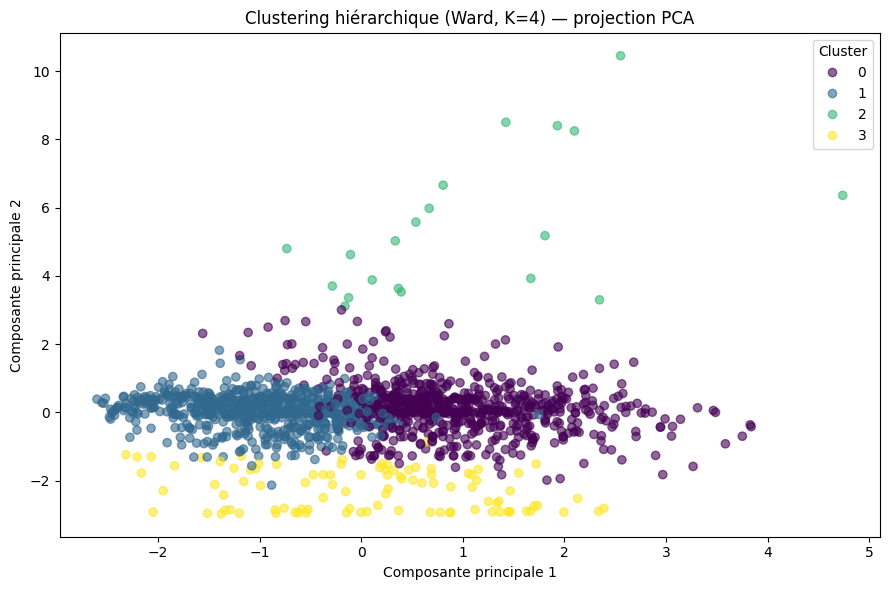

In [6]:
# =========================
# VISUALISATION PCA 2D
# =========================
X2 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(df)
plt.figure(figsize=(9, 6))
scatter = plt.scatter(X2[:, 0], X2[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.legend(*scatter.legend_elements(), title="Cluster")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title(f"Clustering hiérarchique (Ward, K={K_FINAL}) — projection PCA")
plt.tight_layout()
plt.show()

## 5. Comparaison avec K-means (TP2)

Les deux méthodes (K-means au TP2, hiérarchique ici) ont travaillé sur **les mêmes données**. On vérifie si elles trouvent **la même structure** en croisant leurs affectations (tableau de contingence). Si les deux méthodes s'accordent, la segmentation en 4 groupes est **robuste** (elle ne dépend pas du choix de l'algorithme).


In [7]:
# =========================
# COMPARAISON K-means vs Hiérarchique (sur les mêmes données)
# =========================
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

# K-means K=4 (reproduit le modèle final du TP2)
km = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10).fit(df)
labels_kmeans = km.labels_
labels_hier = labels  # hiérarchique Ward K=4 calculé plus haut

# Tableau de contingence : combien de districts en commun entre chaque paire de clusters
contingence = pd.crosstab(
    pd.Series(labels_hier, name='Hiérarchique'),
    pd.Series(labels_kmeans, name='K-means')
)
print("Tableau de contingence (lignes = hiérarchique, colonnes = K-means) :")
print(contingence)

# Adjusted Rand Index : mesure l'accord entre 2 clusterings (1 = identique, 0 = hasard)
ari = adjusted_rand_score(labels_hier, labels_kmeans)
print(f"\nAdjusted Rand Index (accord entre les 2 méthodes) : {ari:.3f}")
print("(1.0 = partitions identiques, 0 = aucun rapport)")

Tableau de contingence (lignes = hiérarchique, colonnes = K-means) :
K-means        0    1   2    3
Hiérarchique                  
0             53   63   1  580
1             19  668   0   24
2              0    0  20    0
3             93    3   0    0

Adjusted Rand Index (accord entre les 2 méthodes) : 0.705
(1.0 = partitions identiques, 0 = aucun rapport)


## 6. Conclusion

**Démarche.** Réutilisation des données préparées au TP2 → construction du **dendrogramme** (Ward) → réglage fin (comparaison de 4 linkages × K) → détection du **piège de la silhouette** (single/average dégénérés) → choix de **Ward, K=4** → profils métier → **comparaison avec K-means**.

**Choix d'outils justifiés (B202).**
- *Clustering hiérarchique* : ne nécessite pas de fixer K à l'avance ; le dendrogramme aide à visualiser la structure et à choisir le nombre de groupes.
- *Linkage de Ward* : seul à produire des clusters équilibrés et exploitables (les autres linkages créent un cluster géant par effet de chaînage). Cohérent avec le cours (« analogue de K-means »).
- *Vérification des tailles de clusters* : indispensable, car un score de silhouette élevé peut masquer un clustering dégénéré.

**Les 4 segments** retrouvés sont les mêmes qu'au TP2 : Pionniers, Aisés, Défavorisés, Très grands districts.

**Résultat clé — robustesse.** Le tableau de contingence et l'**Adjusted Rand Index** montrent un fort accord entre K-means et le clustering hiérarchique : **deux algorithmes différents trouvent essentiellement la même segmentation**. Cela **valide** la structure en 4 groupes — ce n'est pas un artefact d'une méthode, mais une vraie structure des données.

**Limites & pistes (B206).** Silhouette modérée (chevauchement partiel des groupes, normal sur données réelles). Le clustering hiérarchique est aussi plus coûteux que K-means (O(N²)), donc moins adapté à de très gros volumes. Piste : tester un clustering basé densité (DBSCAN, TP5) pour gérer d'éventuelles formes non sphériques.
